<a href="https://colab.research.google.com/github/giuseppe-maffucci-01/happo-training-mlp/blob/main/HAPPO_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Library imports and environment setup:** this cell handles the installation of required external dependencies and imports all Python modules necessary for implementing the Heterogeneous-Agent Proximal Policy Optimization (HAPPO) algorithm and managing the execution environment.

In [20]:
!pip install gymnasium
!pip install git+https://github.com/giorgiofranceschelli/Gymnasium-Stag-Hunt.git

import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions.categorical import Categorical
import math
import json
import gymnasium as gym
import gymnasium_stag_hunt
from gymnasium_stag_hunt.envs.gym.hunt import HuntEnv
import numpy as np
from gymnasium_stag_hunt.src.utils import place_entity_in_unoccupied_cell, spawn_plants
import functools
from torch.nn.utils import clip_grad_norm_
import matplotlib.pyplot as plt
from torch.optim.lr_scheduler import LambdaLR

  Cloning https://github.com/giorgiofranceschelli/Gymnasium-Stag-Hunt.git to /tmp/pip-req-build-p5bm6zr1
  Running command git clone --filter=blob:none --quiet https://github.com/giorgiofranceschelli/Gymnasium-Stag-Hunt.git /tmp/pip-req-build-p5bm6zr1
  Resolved https://github.com/giorgiofranceschelli/Gymnasium-Stag-Hunt.git to commit 39b6b5d6c653dd38655288930c660faff9b2fb01
  Preparing metadata (setup.py) ... done


**Configuration & hyperparameter setup**: this cell establishes all operational parameters and training hyperparameters for the HAPPO execution pipeline. The configurations are divided into environment initialization specs, agent structural parameters, and optimization hyperparameters

In [21]:
from dataclasses import dataclass, field
from typing import Dict, Any

# -----------------------------------------------------------------------------
# Environment Configurations
# -----------------------------------------------------------------------------
GAME_TYPE: str = "Hunt"  # Options: "Hunt", "Harvest", "Escalation"
SHOW_STREAK_TO_ACTORS: bool = True  # Relevant for Escalation mode tracking
N_ENVS: int = 16  # Number of vectorized environments run in parallel

ENV_CONFIGS: Dict[str, Any] = {
    "obs_type": "coords",  # Coordinates format: [A_x, A_y, B_x, B_y, S_x, S_y, P1_x, P1_y, ...]
    "enable_multiagent": True,
    "load_renderer": False,
}

# -----------------------------------------------------------------------------
# Agent & Horizon Parameters
# -----------------------------------------------------------------------------
NUM_AGENTS: int = 2  # Number of agents in the multi-agent system (NOTE THAT THIS CODE IMPLEMENTATION IS JUST FOR 2 AGENTS, SO PLEASE DO NOT CHANGE THIS NUMBER!!)
OUTPUT_DIM: int = 5  # Action space dimension (UP, DOWN, LEFT, RIGHT, STAY)
T_HORIZON: int = 300  # Steps collected per roll-out generation phase

# -----------------------------------------------------------------------------
# Training Hyperparameters
# -----------------------------------------------------------------------------
K_ITERATIONS: int = 200  # Total HAPPO optimization iterations
WARMUP_K: int = int(K_ITERATIONS * 0.05)  # Learning rate warmup period (5% of K)

LR_ACTOR: float = 3e-4  # Actor network learning rate
LR_CRITIC: float = 1e-3  # Centralized critic network learning rate

ACTOR_EPOCHS: int = 3  # Optimization epochs per HAPPO iteration (Actor)
CRITIC_EPOCHS: int = 5  # Optimization epochs per HAPPO iteration (Critic)
NUM_MINI_BATCH: int = 4  # Mini-batches generated per epoch

EPS_CLIP: float = 0.2  # PPO surrogate clipping coefficient
VALUE_LOSS_COEF: float = 0.5  # Critic value loss coefficient weight
ENTROPY_COEF: float = 0.01  # Policy entropy regularization coefficient
MAX_GRAD_NORM: float = 0.5  # Maximum gradient norm threshold for clipping

USE_CLIPPED_VALUE_LOSS: bool = False  # Enable clipped value function loss
HUBER_DELTA: float = 10.0  # Threshold parameter for Huber value loss computation

# -----------------------------------------------------------------------------
# Rewards/Advantages Parameters
# -----------------------------------------------------------------------------
GAMMA_GAE: float = 0.99
GAMMA_REWARD_SHAPING: float = 0.99
ALPHA_REWARD_SHAPING: float = 0.1


**Agent Networks: Actor and Centralized Critic**

This cell defines the neural network architectures for the multi-agent framework:

**Actor**: Local policy network mapping individual observations to categorical action distributions. Incorporates action sampling, log-probability/entropy evaluation, and the HAPPO surrogate loss calculation

**Critic**: Centralized value function network

In [22]:
from typing import Tuple, Union


class Actor(nn.Module):
    """
    Local Actor Network for individual policy parameterization.
    """

    def __init__(self, input_dim: int, output_dim: int, lr: float = 3e-4):
        super().__init__()
        self.norm = nn.LayerNorm(input_dim)
        self.hidden_layers = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
        )
        self.out = nn.Linear(128, output_dim)
        self.optimizer = torch.optim.Adam(self.parameters(), lr=lr) #optimizer, used later

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.norm(x)
        x = self.hidden_layers(x)
        return self.out(x)  # #out[0] = UP, out[1] = DOWN, out[2] = LEFT, out[3] = RIGHT, out[4] = STAY, see torch.multinomial in self.generate_action

    def generate_action(self, input_obs: torch.Tensor, temperature: float = 1.0) -> torch.Tensor:
        logits = self(input_obs)
        probs = F.softmax(logits / temperature, dim=-1)
        action = torch.multinomial(probs, num_samples=1)
        return action #shape: (num_envs, 1)

    def evaluate_actions(self, obs: torch.Tensor, actions: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        logits = self(obs)
        dist = Categorical(logits=logits)

        if isinstance(actions, torch.Tensor):
            actions = actions.squeeze(-1).long()
        else:
            actions = torch.tensor(actions, device=logits.device).long()

        log_probs = dist.log_prob(actions).unsqueeze(-1) #shape: (B, 1)
        entropy = dist.entropy().unsqueeze(-1) #shape: (B, 1)

        return log_probs, entropy

    def compute_actor_loss(
            self,
            new_log_prob: torch.Tensor,
            old_log_prob_batch: torch.Tensor,
            factor_m_batch: torch.Tensor,
            adv_batch: torch.Tensor,
            entropy: torch.Tensor,
            eps_clip: float,
            entropy_coef: float,
        ) -> torch.Tensor:
        """
        Computes HAPPO clipped surrogate policy loss with entropy regularization.
        """

        imp_weights = torch.exp(new_log_prob - old_log_prob_batch) #importance sampling ratio for the current agent

        effective_adv = factor_m_batch * adv_batch #advantage weighted by factor M comuled from previous agents

        # PPO-Clip objective
        surr1 = imp_weights * effective_adv
        surr2 = torch.clamp(imp_weights, 1.0 - eps_clip, 1.0 + eps_clip) * effective_adv

        policy_loss = -torch.min(surr1, surr2).mean() # - E(L_clip)
        entropy_loss = -entropy_coef * entropy.mean() # - coeff*E(H)

        return policy_loss + entropy_loss # L_actor = -E(L_clip + coeff*H) = - (E(L_clip) + coeff*E(H))



class Critic(nn.Module):
    """
    Centralized Critic Network evaluating global system state values V(s).
    """

    def __init__(self, input_dim: int, lr: float = 1e-3):
        super().__init__()
        self.norm = nn.LayerNorm(input_dim)
        self.hidden_layers = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
        )
        self.out = nn.Linear(128, 1)
        self.optimizer = torch.optim.Adam(self.parameters(), lr=lr)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.norm(x)
        x = self.hidden_layers(x)
        return self.out(x)

    def huber_loss(self, e: torch.Tensor, delta: float = 10.0) -> torch.Tensor:
        """
        Calculates element-wise Huber loss function.
        """
        abs_e = torch.abs(e)
        return torch.where(abs_e <= delta, 0.5 * (e ** 2), delta * (abs_e - 0.5 * delta))



    def compute_critic_loss(
        self,
        old_v_preds_batch: torch.Tensor,
        v_preds: torch.Tensor,
        returns_batch: torch.Tensor,
        eps_clip: float,
        huber_delta: float,
        use_clipped_value_loss: bool,
    ) -> torch.Tensor:
        """
        Calculates centralized critic loss with optional value clipping.
        """
        if use_clipped_value_loss:
            v_pred_clipped = old_v_preds_batch + torch.clamp(v_preds - old_v_preds_batch, -eps_clip, eps_clip)
            error_original = returns_batch - v_preds
            error_clipped = returns_batch - v_pred_clipped

            loss_original = self.huber_loss(error_original, huber_delta)
            loss_clipped = self.huber_loss(error_clipped, huber_delta)
            critic_loss = torch.max(loss_original, loss_clipped).mean()
        else:
            error = returns_batch - v_preds
            critic_loss = self.huber_loss(error, huber_delta).mean()
        return critic_loss



**WRAPPERS AND ADAPTERS DEFINITIONS**

**Wrappers definitions**:
the 3 wrappers below ar just for single gym environment then happo_vector_adapter considers a vector of envoronments, each with one of these interfaces and creates the propers structures to be interfaced with HAPPO buffer

In [23]:
class StagHuntWrapper(gym.Wrapper): #this wrapper is just for a single gym environment
    def __init__(self, env, min_stag_dist=2):
        super().__init__(env)
        self.min_stag_dist = min_stag_dist
        self.action_space = gym.spaces.MultiDiscrete([5, 5])

    def reset(self, seed=None, options=None):
        obs, info = self.env.reset(seed=seed, options=options)
        game = self.env.unwrapped.game
        grid_dims = game.GRID_DIMENSIONS

        game.A_AGENT = place_entity_in_unoccupied_cell(grid_dims=grid_dims, used_coordinates=[])
        game.B_AGENT = place_entity_in_unoccupied_cell(grid_dims=grid_dims, used_coordinates=[game.A_AGENT])

        ax, ay = int(game.A_AGENT[0]), int(game.A_AGENT[1])
        bx, by = int(game.B_AGENT[0]), int(game.B_AGENT[1])

        while True: #place the stag at least 2 units far (in terms of manhattan distance) from the agents
            stag_pos = place_entity_in_unoccupied_cell(
                grid_dims=grid_dims,
                used_coordinates=[game.A_AGENT, game.B_AGENT]
            )
            sx, sy = int(stag_pos[0]), int(stag_pos[1])
            dist_a = abs(sx - ax) + abs(sy - ay)
            dist_b = abs(sx - bx) + abs(sy - by)
            if dist_a >= self.min_stag_dist and dist_b >= self.min_stag_dist:
                break

        game.STAG = stag_pos
        game.PLANTS = spawn_plants(
            grid_dims=grid_dims,
            how_many=game._forage_quantity,
            used_coordinates=game.AGENTS + [game.STAG],
        )
        game._tagged_plants = []
        game._timestep = 0

        obs_list = game.get_observation() #local observations of the single environment

        return obs_list, info #to be coherent with gymnasium, it wants obs and info in the reset() function

    def step(self, actions_sent): #for each environment actions_sent is [act_a, act_b]
        next_obs_list, rewards, terminated, truncated, info = self.env.step(actions_sent)
        game = self.env.unwrapped.game

        r_a, r_b = rewards
        stag_caught = (r_a == game._stag_reward and r_b == game._stag_reward)
        agent_mauled = (r_a == game._mauling_punishment or r_b == game._mauling_punishment)

        custom_done = (stag_caught or agent_mauled)

        if custom_done: #reset to start a new game
            next_obs_list, info = self.reset()

        info['rewards_a_b'] = np.array([r_a, r_b], dtype=np.float32)
        info['custom_done'] = custom_done
        global_reward = float(r_a + r_b)

        return next_obs_list, global_reward, terminated, truncated, info #gymnasium wants: obs, reward, terminated, truncated, info


class HarvestWrapper(gym.Wrapper): #this wrapper is just for a single gym environment
    def __init__(self, env, min_plant_dist=2):
        super().__init__(env)
        self.min_plant_dist = min_plant_dist
        self.action_space = gym.spaces.MultiDiscrete([5, 5])

    def reset(self, seed=None, options=None):
        obs, info = self.env.reset(seed=seed, options=options)
        game = self.env.unwrapped.game
        grid_dims = game.GRID_DIMENSIONS

        game.A_AGENT = np.array(place_entity_in_unoccupied_cell(grid_dims=grid_dims, used_coordinates=[]), dtype=np.uint8)
        game.B_AGENT = np.array(place_entity_in_unoccupied_cell(grid_dims=grid_dims, used_coordinates=[game.A_AGENT]), dtype=np.uint8)

        ax, ay = int(game.A_AGENT[0]), int(game.A_AGENT[1])
        bx, by = int(game.B_AGENT[0]), int(game.B_AGENT[1])

        for plant_number in range(game._max_plants):
            while True:
                plant_pos = place_entity_in_unoccupied_cell(
                    grid_dims=grid_dims,
                    used_coordinates=[game.A_AGENT, game.B_AGENT]
                )
                sx, sy = int(plant_pos[0]), int(plant_pos[1])
                dist_a = abs(sx - ax) + abs(sy - ay)
                dist_b = abs(sx - bx) + abs(sy - by)
                if dist_a >= self.min_plant_dist and dist_b >= self.min_plant_dist:
                    break

            game._plants[plant_number] = np.array(plant_pos, dtype=np.uint8)

        game._maturity_flags = [False] * game._max_plants
        game._timestep = 0

        obs_list = [np.array(o, dtype=np.uint8) for o in game.get_observation()]

        return obs_list, info

    def step(self, actions_sent):
        next_obs_list, rewards, terminated, truncated, info = self.env.step(actions_sent)
        next_obs_list = [np.array(o, dtype=np.uint8) for o in next_obs_list]

        r_a, r_b = rewards
        global_reward = float(r_a + r_b)

        info['rewards_a_b'] = np.array([r_a, r_b], dtype=np.float32)
        info['custom_done'] = terminated or truncated

        return next_obs_list, global_reward, terminated, truncated, info



class EscalationWrapper(gym.Wrapper):  #this wrapper is just for a single gym environment
    def __init__(self, env, min_mark_dist=2, gamma_shaping=0.99, alpha_shaping=0.1, max_streak=10):
        super().__init__(env)
        self.min_mark_dist = min_mark_dist
        self.gamma_shaping = gamma_shaping
        self.alpha_shaping = alpha_shaping
        self.max_streak = max_streak
        self.action_space = gym.spaces.MultiDiscrete([5, 5])
        self.current_phi = 0.0


    def _calc_phi(self, game): #compute the manhattan distances from agents and mark and sum them
        ax, ay = int(game.A_AGENT[0]), int(game.A_AGENT[1])
        bx, by = int(game.B_AGENT[0]), int(game.B_AGENT[1])
        mx, my = int(game._mark[0]), int(game._mark[1])

        dist_a = abs(ax - mx) + abs(ay - my)
        dist_b = abs(bx - mx) + abs(by - my)
        return float(dist_a + dist_b)


    def reset(self, seed=None, options=None):
        obs, info = self.env.reset(seed=seed, options=options)
        game = self.env.unwrapped.game
        grid_dims = game.GRID_DIMENSIONS

        game.A_AGENT = np.array(place_entity_in_unoccupied_cell(grid_dims=grid_dims, used_coordinates=[]), dtype=np.uint8)
        game.B_AGENT = np.array(place_entity_in_unoccupied_cell(grid_dims=grid_dims, used_coordinates=[game.A_AGENT]), dtype=np.uint8)

        ax, ay = int(game.A_AGENT[0]), int(game.A_AGENT[1])
        bx, by = int(game.B_AGENT[0]), int(game.B_AGENT[1])

        while True:
            mark_pos = place_entity_in_unoccupied_cell(
                grid_dims=grid_dims,
                used_coordinates=[game.A_AGENT, game.B_AGENT]
            )
            mx, my = int(mark_pos[0]), int(mark_pos[1])
            dist_a = abs(mx - ax) + abs(my - ay)
            dist_b = abs(mx - bx) + abs(my - by)
            if dist_a >= self.min_mark_dist and dist_b >= self.min_mark_dist:
                break

        game._mark = np.array(mark_pos, dtype=np.uint8) #assigns the mark
        game._streak = 0 #reset the streak
        game._streak_active = False
        game._timestep = 0

        self.current_phi = self._calc_phi(game) #initial potential (Phi(o_0))

        obs_list = game.get_observation()
        info = {
          'streak': game._streak,
          'custom_done': False
        }

        return obs_list, info

    def step(self, actions_sent):
        next_obs_list, rewards, terminated, truncated, info = self.env.step(actions_sent)
        game = self.env.unwrapped.game

        r_a, r_b = rewards
        base_reward = float(r_a + r_b)

        next_phi = self._calc_phi(game)
        f_shaping = self.current_phi - (self.gamma_shaping * next_phi) #potential-based Reward Shaping
        self.current_phi = next_phi

        global_reward = base_reward + (self.alpha_shaping * f_shaping)

        streak_broken = (not game._streak_active and (r_a < 0 or r_b < 0)) #check custom end game conditions
        streak_completed = (game._streak >= self.max_streak)

        custom_done = streak_broken or streak_completed or terminated or truncated

        if custom_done: #game ended: reset environment
            next_obs_list, info = self.reset()
        else:
            next_obs_list = game.get_observation() #coherent with gymnasium

        info["rewards_a_b"] = np.array([r_a, r_b], dtype=np.float32)
        info["custom_done"] = custom_done
        info["streak"] = game._streak

        return next_obs_list, global_reward, terminated, truncated, info

**Definition of HAPPO vector adapter and function that makes the environments vector**

In [24]:
def happo_vector_adapter(envs, show_streak_to_actors=True): #needed to create an interface the syncvector of envs with wrappers and the HAPPO buffer
    orig_reset = envs.reset
    orig_step = envs.step

    def _format_obs(raw_obs, infos):
        n_envs = len(raw_obs)
        num_agents = len(raw_obs[0])

        is_escalation = getattr(envs.envs[0].unwrapped, "game_title", "").lower() == "escalation" #if escalation we have have additional things to consider

        obs = [ #actor observations
            torch.tensor(
                [
                    np.append(raw_obs[b][m], infos['streak'][b])
                    if (show_streak_to_actors and is_escalation)
                    else raw_obs[b][m]
                    for b in range(n_envs)
                ],
                dtype=torch.float32
            )
            for m in range(num_agents)
        ]

        if is_escalation:
            if show_streak_to_actors:
                centr_obs = obs[0] #if actors see the streak, we utlize directly it in the critic observations
            else:
                centr_obs_list = [ #if actors do not see the streak, we append it anyway to the critic observations
                    np.append(raw_obs[b][0], infos['streak'][b])
                    for b in range(n_envs)
                ]
                centr_obs = torch.tensor(np.array(centr_obs_list), dtype=torch.float32) # critic observations in Escalation
        else:

            centr_obs = obs[0] #critic observations in Hunt / Harvest

        return centr_obs, obs

    @functools.wraps(orig_reset)
    def custom_reset(*args, **kwargs):
        raw_obs, infos = orig_reset(*args, **kwargs)
        centr_obs, obs = _format_obs(raw_obs, infos)
        return centr_obs, obs, infos

    @functools.wraps(orig_step)
    def custom_step(actions, *args, **kwargs):
        actions_sent = [
            [actions[m][b].item() for m in range(len(actions))]
            for b in range(len(actions[0]))
        ]

        raw_obs, rewards, terminations, truncations, infos = orig_step(actions_sent, *args, **kwargs)
        centr_obs, obs = _format_obs(raw_obs, infos)

        global_rewards = torch.tensor(rewards, dtype=torch.float32).view(-1, 1)
        custom_dones = np.array(infos['custom_done'], dtype=np.float32)
        dones_t = torch.tensor(custom_dones, dtype=torch.float32).view(-1, 1)

        return centr_obs, obs, global_rewards, dones_t, terminations, truncations, infos

    envs.reset = custom_reset
    envs.step = custom_step
    return envs



def make_env(game_name, game_configs):
    env = gym.make(f"StagHunt-{game_name}-v0", **game_configs)
    if game_name == "Hunt":
        return StagHuntWrapper(env, min_stag_dist=2)
    elif game_name == "Harvest":
        return HarvestWrapper(env, min_plant_dist=2)
    elif game_name == "Escalation":
        return EscalationWrapper(env, min_mark_dist=2, gamma_shaping=GAMMA_REWARD_SHAPING, alpha_shaping=ALPHA_REWARD_SHAPING)
    else:
        raise ValueError(f"Game {game_name} not implemented")

**HAPPO buffer definition:** this buffer is filled at each iteration **k** of the algorithm and it is used to store the datas to update Actors and Critic for several epochs on each iteration. As we will see later on, the updating epochs for the actors are different from the updating epochs for the critic

In [25]:
class HAPPOBuffer():
    def __init__(self, num_agents, num_envs, generation_lenght, obs_shape, share_obs_shape, act_shape, log_probs_shape):
        self.num_agents = num_agents
        self.B = num_envs
        self.T = generation_lenght
        self.obs_shape = obs_shape
        self.share_obs_shape = share_obs_shape
        self.act_shape = act_shape

        self.share_obs = torch.zeros((self.B, self.T, *share_obs_shape)) #observation to be given to the criti model
        self.rewards = torch.zeros((self.B, self.T, 1)) #rt = global rewards from the environment
        self.dones = torch.zeros((self.B, self.T, 1)) #needed to compute the GAE
        self.value_preds = torch.zeros((self.B, self.T, 1)) #values predicted by the value network
        self.advantages = torch.zeros((self.B, self.T, 1)) #computed with GAE
        self.returns = torch.zeros((self.B, self.T, 1)) #reward to go, GAE + Value(centr_state)

        # local buffers for each agent
        self.obs = [torch.zeros((self.B, self.T, *obs_shape[i])) for i in range(num_agents)] #obs for each agent
        self.actions = [torch.zeros((self.B, self.T, *act_shape[i])) for i in range(num_agents)] #act_shape = 1 in our case      actions for each agent
        self.action_log_probs = [torch.zeros((self.B, self.T, *log_probs_shape[i])) for i in range(num_agents)]  #log_probs_shape = 1 in our case       logps for each agent

        # M^{i_1:m-1} in HAPPO paper
        self.factor_m = torch.ones((self.B * self.T, 1), dtype=torch.float32)


    def reset_factor_m(self): #reset at the beginning of the agents loop
        self.factor_m.fill_(1.0)

    def update_factor_m_minibatch(self, mb_indices, new_log_prob, old_log_prob_batch): #updates M at current indices, so that we do not run the model in the entire B*T data at once (useful for future extentions to LLMs)
        with torch.no_grad():
            ratio = torch.exp(new_log_prob - old_log_prob_batch)
            self.factor_m[mb_indices] *= ratio

    def compute_gae(self, next_value, gamma=GAMMA_GAE, gae_lambda=0.95):
        lastgaelam = 0.0

        for t in reversed(range(self.T)):
            if t == self.T - 1:
                next_val = next_value
            else:
                next_val = self.value_preds[:, t + 1]
            non_terminal = 1.0 - self.dones[:, t]  #custom done seen in the wrappers
            delta = self.rewards[:, t] + gamma * next_val * non_terminal - self.value_preds[:, t]  #TD-Error
            self.advantages[:, t] = lastgaelam = delta + gamma * gae_lambda * non_terminal * lastgaelam  #GAE accumulation

        self.returns = self.advantages + self.value_preds #critic target, used in critic loss

    @torch.no_grad
    def fill_buffer(self, envs, agents, critic, gamma=GAMMA_GAE, gae_lambda=0.95): #this function fills the buffer and it is used at each iteration K
        centr_obs, obs, infos = envs.reset()

        curr_act = [torch.zeros((self.B, *self.act_shape[m])) for m in range(self.num_agents)]
        curr_obs = [torch.zeros_like(obs[m]) for m in range(self.num_agents)]
        curr_centr_obs = torch.zeros_like(centr_obs)
        curr_centr_obs.copy_(centr_obs)

        for m in range(len(agents)):
            curr_obs[m].copy_(obs[m])

        for t in range(self.T): #t=step of the generations
            for m in range(len(agents)):
                curr_act[m].copy_(agents[m].generate_action(curr_obs[m])) #(current_act[m] is a tensor of shape (N_ENVS, *act_shape[m]) )
                self.obs[m][:, t, :].copy_(curr_obs[m])
                self.actions[m][:, t, :].copy_(curr_act[m]) #(N_ENVS, *action_space_shape)

                log_p, _ = agents[m].evaluate_actions(curr_obs[m], curr_act[m])
                self.action_log_probs[m][:, t, :].copy_(log_p)

            self.share_obs[:, t, :].copy_(curr_centr_obs)
            self.value_preds[:, t, :].copy_(critic(curr_centr_obs)) #(N_ENVS, 1)

            next_centr_obs, next_obs, global_rewards, dones_t, terminated, truncated, infos = envs.step(curr_act)

            self.rewards[:, t, :].copy_(global_rewards) #r_t (N_ENVS, 1)
            self.dones[:, t, :].copy_(dones_t)

            curr_centr_obs.copy_(next_centr_obs)
            for m in range(len(agents)):
                curr_obs[m].copy_(next_obs[m])

        with torch.no_grad(): #centralized observation
            next_value = critic(curr_centr_obs) # Shape: (N_ENVS, 1)

        self.compute_gae(next_value, gamma, gae_lambda)

In [26]:
def _get_cosine_schedule(
    current_step: int,
    num_training_steps: int,
    num_warmup_steps: int = 10,
    linear_warmup: bool = True,
    min_value: float = 0.1,
):
    if current_step < num_warmup_steps:
        if linear_warmup:
            return min(1.0, (current_step + 1) / (num_warmup_steps + 1))
        else:
            return 1.0
    progress = float(current_step - num_warmup_steps) / float(max(1, num_training_steps - num_warmup_steps))
    scale = 0.5 * (1.0 + math.cos(math.pi * progress))
    return (1.0 - min_value) * scale + min_value

In [27]:
class HAPPO_trainer():
    def __init__(self,
                 agents,
                 critic,
                 agents_schedulers,
                 critic_schedulers,
                 happo_buffer,
                 eps_clip,
                 value_loss_coef,
                 entropy_coef,
                 max_grad_norm,
                 use_clipped_value_loss,
                 huber_delta):
        self.agents = agents
        self.critic = critic
        self.happo_buffer = happo_buffer
        self.agents_schedulers = agents_schedulers
        self.critic_schedulers = critic_schedulers
        self.eps_clip = eps_clip
        self.value_loss_coef = value_loss_coef
        self.entropy_coef = entropy_coef
        self.max_grad_norm = max_grad_norm
        self.use_clipped_value_loss = use_clipped_value_loss
        self.huber_delta = huber_delta

    def train(self, envs, K_iterations, actor_epochs, critic_epochs, num_mini_batch):
        num_agents = len(self.agents)
        history = {
            "rewards": [],
            "critic_loss": [],
            "actor_losses": {m: [] for m in range(num_agents)},
            "entropies": {m: [] for m in range(num_agents)},
        }

        for k in range(K_iterations):

            self.happo_buffer.fill_buffer(envs, self.agents, self.critic)

            B, T = self.happo_buffer.advantages.shape[0], self.happo_buffer.advantages.shape[1]
            batch_size = B * T
            mini_batch_size = batch_size // num_mini_batch

            mean_iteration_reward = self.happo_buffer.rewards.sum(dim=1).mean().item()
            history["rewards"].append(mean_iteration_reward)

            adv_flat = self.happo_buffer.advantages.view(batch_size, 1)
            norm_adv_flat = (adv_flat - adv_flat.mean()) / (adv_flat.std() + 1e-8)


            iter_actor_losses = {m: [] for m in range(num_agents)}
            iter_entropies = {m: [] for m in range(num_agents)}


            self.happo_buffer.reset_factor_m()
            permuted_agents = torch.randperm(num_agents).tolist()
            for m in permuted_agents:
                agent = self.agents[m]
                obs_flat = self.happo_buffer.obs[m].view(batch_size, -1)
                act_flat = self.happo_buffer.actions[m].view(batch_size, -1)
                old_log_prob_flat = self.happo_buffer.action_log_probs[m].view(batch_size, 1)

                for epoch in range(actor_epochs):

                    rand_indices = torch.randperm(batch_size)

                    for mini_batch_idx in range(num_mini_batch):
                        start_idx = mini_batch_idx * mini_batch_size
                        end_idx = min(batch_size, start_idx + mini_batch_size)
                        mb_indices = rand_indices[start_idx:end_idx]

                        obs_batch = obs_flat[mb_indices]
                        act_batch = act_flat[mb_indices]
                        old_log_prob_batch = old_log_prob_flat[mb_indices]
                        factor_m_batch = self.happo_buffer.factor_m[mb_indices]
                        adv_batch = norm_adv_flat[mb_indices]


                        new_log_prob, entropy = agent.evaluate_actions(obs_batch, act_batch)

                        actor_loss = agent.compute_actor_loss(
                            new_log_prob,
                            old_log_prob_batch,
                            factor_m_batch,
                            adv_batch,
                            entropy,
                            self.eps_clip,
                            self.entropy_coef
                        )


                        agent.optimizer.zero_grad()
                        actor_loss.backward()
                        clip_grad_norm_(agent.parameters(), self.max_grad_norm)
                        agent.optimizer.step()


                        iter_actor_losses[m].append(actor_loss.item())
                        iter_entropies[m].append(entropy.mean().item())

                for mini_batch_idx in range(num_mini_batch): #update factor m, it requires theta k+1' (k+1' and not k+1 since k+1 is the update after all epochs) so it has to be done after the single epoch update (all minibatches) for each agent
                    start_idx = mini_batch_idx * mini_batch_size
                    end_idx = min(batch_size, start_idx + mini_batch_size)
                    mb_indices = torch.arange(start_idx, end_idx)

                    obs_batch = obs_flat[mb_indices]
                    act_batch = act_flat[mb_indices]
                    old_log_prob_batch = old_log_prob_flat[mb_indices]

                    new_log_prob, _ = agent.evaluate_actions(obs_batch, act_batch)
                    self.happo_buffer.update_factor_m_minibatch(mb_indices, new_log_prob.detach(), old_log_prob_batch)


            for sched in self.agents_schedulers:
                sched.step()


            for m in range(num_agents):
                history["actor_losses"][m].append(sum(iter_actor_losses[m]) / len(iter_actor_losses[m]))
                history["entropies"][m].append(sum(iter_entropies[m]) / len(iter_entropies[m]))

            share_obs_flat = self.happo_buffer.share_obs.view(batch_size, -1)
            returns_flat = self.happo_buffer.returns.view(batch_size, 1)
            old_v_preds_flat = self.happo_buffer.value_preds.view(batch_size, 1)

            iter_critic_losses = []

            for epoch in range(critic_epochs):
                rand_indices = torch.randperm(batch_size)

                for mini_batch_idx in range(num_mini_batch):
                    start_idx = mini_batch_idx * mini_batch_size
                    end_idx = min(batch_size, start_idx + mini_batch_size)
                    mb_indices = rand_indices[start_idx:end_idx]

                    share_obs_batch = share_obs_flat[mb_indices]
                    returns_batch = returns_flat[mb_indices]
                    old_v_preds_batch = old_v_preds_flat[mb_indices]

                    new_v_preds = self.critic(share_obs_batch)

                    c_loss = self.critic.compute_critic_loss(
                        old_v_preds_batch,
                        new_v_preds,
                        returns_batch,
                        self.eps_clip,
                        self.huber_delta,
                        self.use_clipped_value_loss
                    )
                    total_critic_loss = c_loss * self.value_loss_coef

                    self.critic.optimizer.zero_grad()
                    total_critic_loss.backward()
                    clip_grad_norm_(self.critic.parameters(), self.max_grad_norm)
                    self.critic.optimizer.step()

                    iter_critic_losses.append(total_critic_loss.item())

            for sched in self.critic_schedulers:
                sched.step()

            history["critic_loss"].append(sum(iter_critic_losses) / len(iter_critic_losses))

            if (k + 1) % 5 == 0 or k == 0:
                print(f"Iter {k+1}/{K_iterations} | Reward: {mean_iteration_reward:.2f} | Critic Loss: {history['critic_loss'][-1]:.4f}")

        return history


**Training**

In [28]:
envs = gym.vector.SyncVectorEnv([lambda: make_env(game_name = GAME_TYPE, game_configs = ENV_CONFIGS) for _ in range(N_ENVS)])
envs = happo_vector_adapter(envs, show_streak_to_actors=SHOW_STREAK_TO_ACTORS)


num_plants = 0
if GAME_TYPE != "Escalation":
    num_plants = envs.envs[0].unwrapped.game._forage_quantity if GAME_TYPE == "Hunt" else envs.envs[0].unwrapped.game._max_plants

if GAME_TYPE == "Hunt":
    obs_shape = (NUM_AGENTS * 2 + 2 + num_plants * 2)
    centr_obs_shape = obs_shape
    input_dim = obs_shape
    centr_input_dim = centr_obs_shape

elif GAME_TYPE == "Harvest":
    obs_shape = (NUM_AGENTS * 2 + num_plants * 3)
    centr_obs_shape = obs_shape
    input_dim = obs_shape
    centr_input_dim = centr_obs_shape

elif GAME_TYPE == "Escalation":
    obs_shape = (NUM_AGENTS * 2 + 2) + 1 if SHOW_STREAK_TO_ACTORS else (NUM_AGENTS * 2 + 2)
    centr_obs_shape = obs_shape if SHOW_STREAK_TO_ACTORS else obs_shape + 1
    input_dim = obs_shape
    centr_input_dim = centr_obs_shape


agents = [Actor(input_dim, OUTPUT_DIM, lr=LR_ACTOR) for _ in range(NUM_AGENTS)]
critic = Critic(centr_input_dim, lr=LR_CRITIC)


happo_buffer = HAPPOBuffer(
    num_agents = NUM_AGENTS,
    num_envs = N_ENVS,
    generation_lenght = T_HORIZON,
    obs_shape = [(obs_shape,) for _ in range(NUM_AGENTS)],
    share_obs_shape = (centr_obs_shape,),
    act_shape = [(1,) for _ in range(NUM_AGENTS)],
    log_probs_shape = [(1,) for _ in range(NUM_AGENTS)],
)


actor_schedulers = []
for agent in agents:
    sched = LambdaLR(
        agent.optimizer,
        lr_lambda=functools.partial(
            _get_cosine_schedule,
            num_training_steps=K_ITERATIONS,
            num_warmup_steps=WARMUP_K,
            min_value=0.1,
        ),
    )
    actor_schedulers.append(sched)

critic_schedulers = []
critic_scheduler = LambdaLR(
    critic.optimizer,
    lr_lambda=functools.partial(
        _get_cosine_schedule,
        num_training_steps=K_ITERATIONS,
        num_warmup_steps=WARMUP_K,
        min_value=0.1,
    ),
)
critic_schedulers.append(critic_scheduler)


happo_trainer = HAPPO_trainer(
    agents = agents,
    critic = critic,
    agents_schedulers = actor_schedulers,
    critic_schedulers = critic_schedulers,
    happo_buffer = happo_buffer,
    eps_clip = EPS_CLIP,
    value_loss_coef = VALUE_LOSS_COEF,
    entropy_coef = ENTROPY_COEF,
    max_grad_norm = MAX_GRAD_NORM,
    use_clipped_value_loss = USE_CLIPPED_VALUE_LOSS,
    huber_delta = HUBER_DELTA
)


history = happo_trainer.train(envs, K_ITERATIONS, ACTOR_EPOCHS, CRITIC_EPOCHS, NUM_MINI_BATCH)

Iter 1/200 | Reward: -268.69 | Critic Loss: 4.8398
Iter 5/200 | Reward: -276.25 | Critic Loss: 1.1024
Iter 10/200 | Reward: -252.31 | Critic Loss: 1.3441
Iter 15/200 | Reward: -136.69 | Critic Loss: 5.9558
Iter 20/200 | Reward: 78.62 | Critic Loss: 8.3216
Iter 25/200 | Reward: 175.00 | Critic Loss: 7.6861
Iter 30/200 | Reward: 258.94 | Critic Loss: 6.4157
Iter 35/200 | Reward: 295.06 | Critic Loss: 5.3152
Iter 40/200 | Reward: 317.25 | Critic Loss: 5.2702
Iter 45/200 | Reward: 371.50 | Critic Loss: 3.6682
Iter 50/200 | Reward: 384.44 | Critic Loss: 3.3874
Iter 55/200 | Reward: 400.88 | Critic Loss: 3.1490
Iter 60/200 | Reward: 423.50 | Critic Loss: 2.4058
Iter 65/200 | Reward: 393.56 | Critic Loss: 2.8805
Iter 70/200 | Reward: 424.12 | Critic Loss: 2.4760
Iter 75/200 | Reward: 414.44 | Critic Loss: 2.5717
Iter 80/200 | Reward: 419.81 | Critic Loss: 2.4088
Iter 85/200 | Reward: 426.19 | Critic Loss: 2.1240
Iter 90/200 | Reward: 430.44 | Critic Loss: 2.5011
Iter 95/200 | Reward: 434.56 |

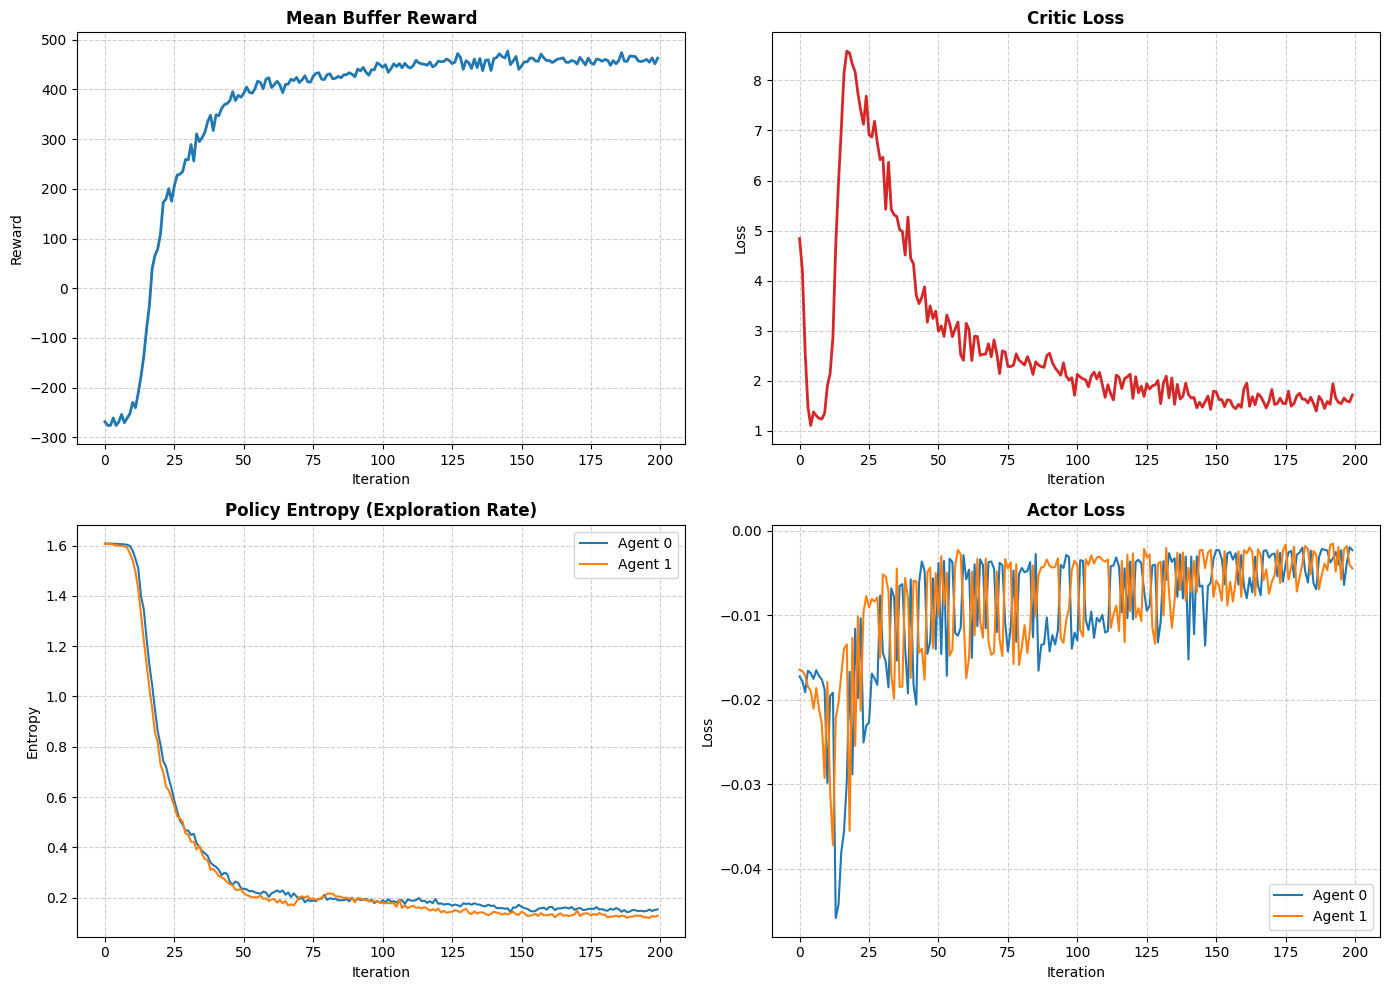

In [30]:
fig, axs = plt.subplots(2, 2, figsize=(14, 10))


axs[0, 0].plot(history["rewards"], color="#1f77b4", linewidth=2)
axs[0, 0].set_title("Mean Buffer Reward", fontsize=12, fontweight="bold")
axs[0, 0].set_xlabel("Iteration")
axs[0, 0].set_ylabel("Reward")
axs[0, 0].grid(True, linestyle="--", alpha=0.6)


axs[0, 1].plot(history["critic_loss"], color="#d62728", linewidth=2)
axs[0, 1].set_title("Critic Loss", fontsize=12, fontweight="bold")
axs[0, 1].set_xlabel("Iteration")
axs[0, 1].set_ylabel("Loss")
axs[0, 1].grid(True, linestyle="--", alpha=0.6)


for m in range(NUM_AGENTS):
    axs[1, 0].plot(history["entropies"][m], label=f"Agent {m}")
axs[1, 0].set_title("Policy Entropy (Exploration Rate)", fontsize=12, fontweight="bold")
axs[1, 0].set_xlabel("Iteration")
axs[1, 0].set_ylabel("Entropy")
axs[1, 0].legend()
axs[1, 0].grid(True, linestyle="--", alpha=0.6)


for m in range(NUM_AGENTS):
    axs[1, 1].plot(history["actor_losses"][m], label=f"Agent {m}")
axs[1, 1].set_title("Actor Loss", fontsize=12, fontweight="bold")
axs[1, 1].set_xlabel("Iteration")
axs[1, 1].set_ylabel("Loss")
axs[1, 1].legend()
axs[1, 1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.savefig("happo_training_metrics.png", dpi=300, bbox_inches="tight")
plt.show()